# Task 1
Підготуйте датасет Chest X-Ray Pneumonia.
- Завантажте зображення.
- Виконайте resize (224×224) і нормалізацію.
- Розділіть дані на train/test.

In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = './data/chest_xray'
subdirs = ['test', 'train', 'val']
mean = [0.485, 0.485, 0.485]
std = [0.229, 0.229, 0.229]

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # transforms.RandomRotation(10),
    # transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.485, 0.485], std=[0.229, 0.229, 0.229])
])

image_datasets = {
    x: datasets.ImageFolder(root=f"{data_dir}/{x}", transform=data_transform) 
    for x in subdirs
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=x=='train', num_workers=4)
    for x in subdirs
}

class_names = image_datasets[subdirs[0]].classes
print(class_names)

['NORMAL', 'PNEUMONIA']


In [7]:
images, labels = next(iter(dataloaders['train']))
print(f"Batch image tensor shape: {images.shape}")
print(f"Batch labels: {labels}")
print(f"Batch classes: {[class_names[i] for i in labels]}")

Batch image tensor shape: torch.Size([32, 3, 224, 224])
Batch labels: tensor([1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 1, 0])
Batch classes: ['PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'NORMAL', 'NORMAL', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA', 'PNEUMONIA', 'NORMAL']


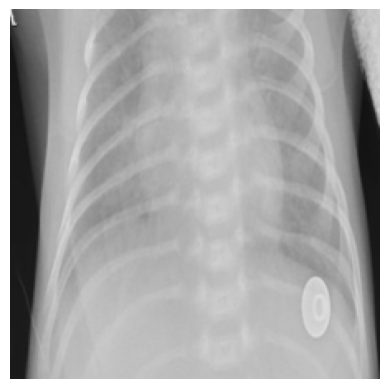

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    npimg = np.transpose(img.numpy(), (1, 2, 0)) * std + mean
    npimg = npimg.clip(0, 1)
    plt.imshow(npimg)
    plt.axis("off")
    plt.show()

imshow(images[0])

In [9]:
images[0].max()

tensor(2.0092)

# Task 2
Використовуйте переднавчену модель ResNet18.
* Заморозьте згорткові шари.
* Замініть класифікатор на новий (Linear(512, 2)).
* Функція втрат: CrossEntropyLoss.
* Оптимізатор: Adam (lr=0.0001).
* Навчіть 5 епох.

In [10]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(512, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in dataloaders['train']:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_loss = running_loss / len(image_datasets['train'])
    print(f"Epochs {epoch+1}/{epochs} | Losses (Loss): {epoch_loss:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\hhj1/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Epochs 1/5 | Losses (Loss): 0.4784
Epochs 2/5 | Losses (Loss): 0.3098
Epochs 3/5 | Losses (Loss): 0.2502
Epochs 4/5 | Losses (Loss): 0.2201
Epochs 5/5 | Losses (Loss): 0.2051


# Task 3
Перевірте якість моделі.
* Порахуйте Accuracy, Precision, Recall і F1-score.
* Побудуйте confusion matrix.
* Збережіть навчену модель у файл pneumonia_resnet18.pth.

Accuracy:  0.7981
Precision: 0.7640
Recall:    0.9795
F1-score:  0.8584


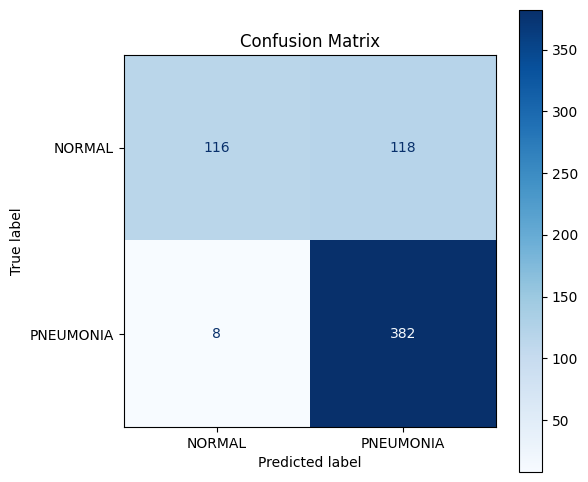

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, pos_label=1)
rec = recall_score(all_labels, all_preds, pos_label=1)
f1 = f1_score(all_labels, all_preds, pos_label=1)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix')
plt.show()

torch.save(model.state_dict(), 'pneumonia_resnet18.pth')

# Task 4
Зробіть візуалізацію результатів.
* Відобразіть 8 випадкових зображень із тестової вибірки.
* Підпишіть передбачений і реальний клас.
* Збережіть графік під іменем pneumonia_predictions.png.
* Зробіть короткий висновок: наскільки модель готова до впровадження?

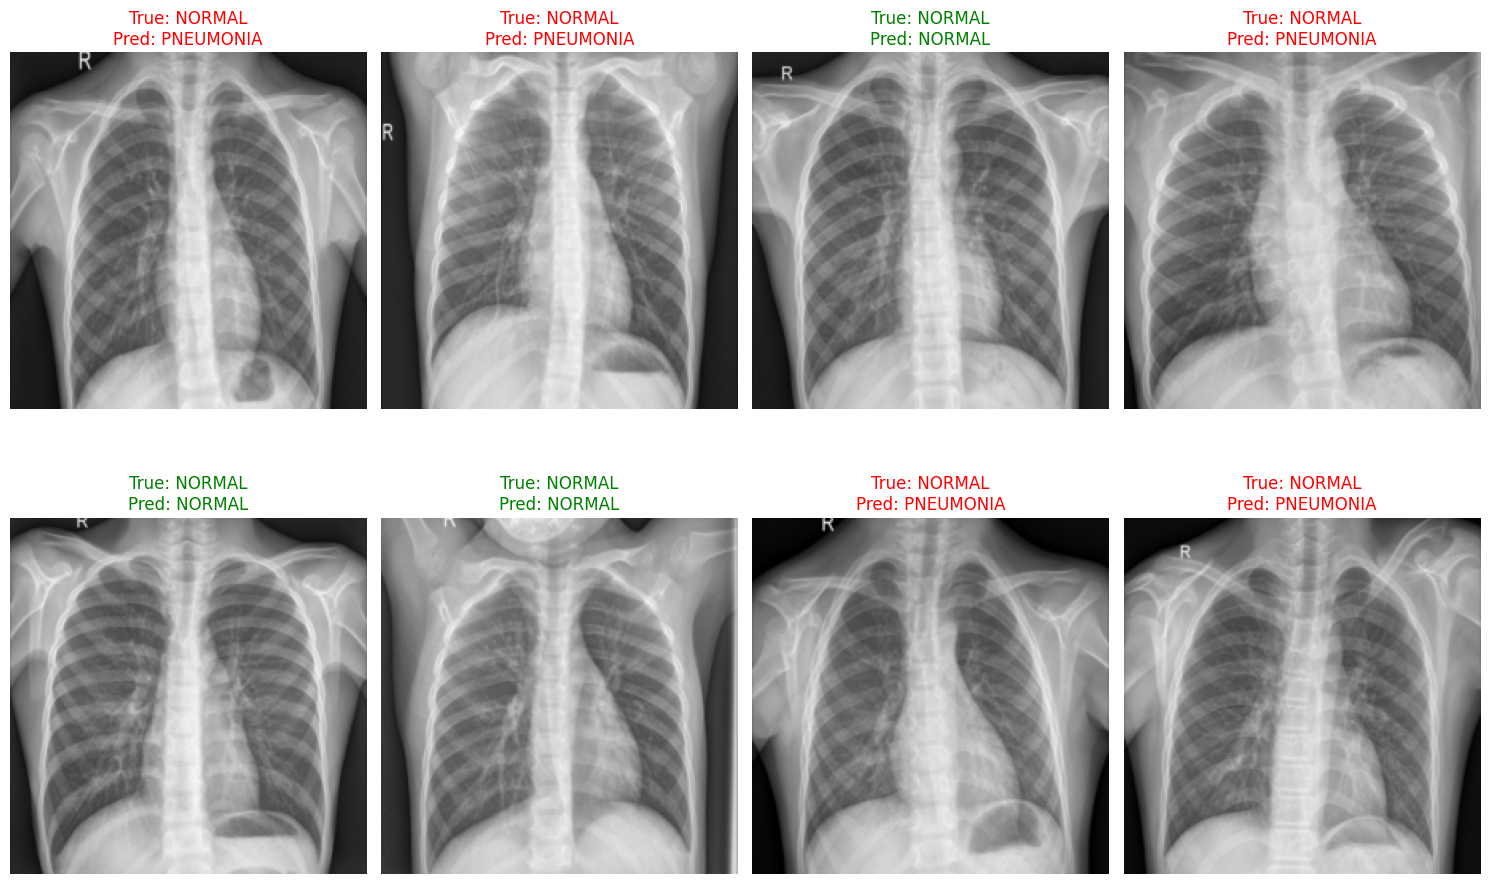


While the ResNet18 model demonstrates strong metrics, it is not yet ready for fully autonomous medical deployment. In diagnostics, Recall is critical to minimize false negatives, as missing a pneumonia diagnosis carries severe risks. Before real-world implementation, this model requires rigorous validation on diverse clinical datasets and regulatory certification. Currently, it is only suitable as a supplementary "second opinion" tool for radiologists.


In [15]:
import numpy as np
from IPython.display import Markdown as md

inputs, labels = next(iter(dataloaders['test']))
inputs, labels = inputs.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    
    img = inputs[i].cpu().numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]
    
    color = 'green' if true_label == pred_label else 'red'
    
    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('pneumonia_predictions.png')
plt.show()

conclusion = """
While the ResNet18 model demonstrates strong metrics, it is not yet ready for fully autonomous medical deployment. In diagnostics, Recall is critical to minimize false negatives, as missing a pneumonia diagnosis carries severe risks. Before real-world implementation, this model requires rigorous validation on diverse clinical datasets and regulatory certification. Currently, it is only suitable as a supplementary "second opinion" tool for radiologists.
"""
md(conclusion)